# TP — Web Sémantique & Machine Learning
## Prédire le succès commercial d'un film
Le fichier n3 de films devient un graphe RDF
interrogeable en SPARQL, qui alimente un pipeline de Machine Learning.

```
N3 → graphe RDF (RDFLib) → SPARQL → NumPy → sklearn → outliers → Wikidata
```

**Règle métier :** un film est un **succès** si `recettes > 2 × budget` (le retour sur investssement ROI > 2).

| Partie | Contenu |
|--------|---------|
| 1 | N3 → graphe RDF (RDF · RDFS · DC · FOAF) |
| 2 | Explorer avec SPARQL |
| 3 | Extraire les données vers NumPy |
| 4 | Normaliser et classifier (DT · KNN · NB) |
| 5 | Clustering sans labels (K-Means · DBSCAN · CAH) |
| 6 | Confronter avec Wikidata |


## Partie 0 — Imports

In [ ]:
!pip install rdflib

In [3]:
import csv, urllib.request, urllib.parse, json
from rdflib import Graph, Namespace, Literal, URIRef, RDF, RDFS, XSD
from rdflib.namespace import FOAF, DC, DCTERMS
from rdflib.plugins.sparql import prepareQuery

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, classification_report,
                             adjusted_rand_score, normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score, silhouette_score, davies_bouldin_score)

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

from rdflib.tools.rdf2dot import rdf2dot

import warnings; warnings.filterwarnings("ignore")


---
## Partie 1 —  Du N3 au graphe RDF

Récupérer le fichier films_data_normes.n3 et le placer dans le même répertoire.
Expliquer ce que dit ce fichier. Les informations de ce fichiers sont des informations synthétiques, créées spécifiquement pour ce TP, rien n'est supposé vrai ni n'a été vérifié.

In [4]:
# Création du graphe
g = Graph()

CIN    = Namespace("http://cinema.fr/vocab#")
FILM   = Namespace("http://cinema.fr/film#")
GENRE  = Namespace("http://cinema.fr/genre#")
SAISON = Namespace("http://cinema.fr/saison#")

# Graphe + préfixes (raccourcis pour la sérialisation)
for prefix, ns in [("rdf",RDF),("rdfs",RDFS),("dc",DC),
                   ("dcterms",DCTERMS),("foaf",FOAF),
                   ("cin",CIN),("film",FILM),("genre",GENRE),("saison",SAISON)]:
    g.bind(prefix, ns)

# Chargement du fichier N3
g.parse("./films_data.n3", format="n3", encoding="utf-8")

# Affichage du nombre de triplets
print(f"Nombre de triplets dans le graphe : {len(g)}")


print(f"\n✓ Base de connaissances créée avec {len(g)} triplets RDF")
print("\nExemple de quelques triplets :")
for i, (s, p, o) in enumerate(g):
    if i < 5:
        print(f"  {s} -> {p} -> {o}")

Nombre de triplets dans le graphe : 1376

✓ Base de connaissances créée avec 1376 triplets RDF

Exemple de quelques triplets :
  http://cinema.fr/film#F022 -> http://cinema.fr/vocab#recettesM -> 966.0
  http://cinema.fr/film#F014 -> http://cinema.fr/vocab#label -> 1
  http://cinema.fr/film#F065 -> http://xmlns.com/foaf/0.1/topic -> http://cinema.fr/saison#hiver
  http://cinema.fr/film#F052 -> http://purl.org/dc/elements/1.1/title -> Detective Pikachu
  http://cinema.fr/film#F066 -> http://purl.org/dc/elements/1.1/date -> 2018


Visualisation du graphe

In [5]:
with open("graph.dot", "w") as f:
    rdf2dot(g, f)

# puis afficher
with open("graph.dot") as f:
    dot_graph = f.read()

#graphviz.Source(dot_graph)

EXERCICE 1 :

⛳ TODO Expliciter la BDD
- remarques ? analyses ?

---
## Partie 2 — Explorer le graphe avec SPARQL


`?f a cin:FilmSucces` est un **patron de triplets** : on cherche toutes
les ressources `?f` de type `cin:FilmSucces`.


In [6]:
# ── Requête 1 : comparer succès et échecs ─────────────────────────────────────
# GROUP BY + agrégats (COUNT, AVG) résument les stats par classe.

qry_stats = prepareQuery("""
    SELECT ?classe (COUNT(?f) AS ?nb)
           (AVG(?budget) AS ?budgetMoy)
           (AVG(?roi) AS ?roiMoy)
           (AVG(?np) AS ?noteMoy)
    WHERE {
        ?f a ?classe ;
           cin:budgetM    ?budget ;
           cin:roi        ?roi ;
           cin:notePresse ?np .

        FILTER(?classe IN (cin:FilmSucces, cin:FilmEchec))
    }
    GROUP BY ?classe
""", initNs={"cin": CIN})

print("Classe", "           ", "N", "      ","Budget moy", "      ","ROI moyen", "      ","Note moy")
print("--------------------------------------------------------------------------------")

for r in g.query(qry_stats):
    classe = str(r.classe).split("#")[-1]
    nb = int(r.nb)
    budget = round(float(r.budgetMoy), 1)
    roi = round(float(r.roiMoy), 2)
    note = round(float(r.noteMoy), 2)

    print(classe, "      ", nb, "      ", budget, "              ", roi, "          ", note)


Classe             N        Budget moy        ROI moyen        Note moy
--------------------------------------------------------------------------------
FilmSucces        64        128.3                8.46            7.38
FilmEchec        21        138.3                0.96            6.23


EXERCICE 2 :

⛳ TODO Récupérer le budget min et max aussi, observer aussi la durée et le nombre de semaines d'exploitation et comparer. Quels seraient les bons attributs pour construire un modèle de classification ?

In [13]:
# ── Requête 1 : comparer succès et échecs ─────────────────────────────────────
# GROUP BY + agrégats (COUNT, AVG) résument les stats par classe.

qry_stats = prepareQuery("""
    SELECT ?classe (COUNT(?f) AS ?nb)
    
           (AVG(?budget) AS ?budgetMoy)
           (MIN(?budget) AS ?budgetMin)
           (MAX(?budget) AS ?budgetMax)
           
           (AVG(?duree) AS ?dureeMoy)
           (MIN(?duree) AS ?dureeMin)
           (MAX(?duree) AS ?dureeMax)
           
           (AVG(?sem) AS ?semaineMoy)
           (MIN(?sem) AS ?semaineMin)
           (MAX(?sem) AS ?semaineMax)
           
           (AVG(?roi) AS ?roiMoy)
           (AVG(?np) AS ?noteMoy)
    WHERE {
        ?f a ?classe ;
           cin:budgetM    ?budget ;
           cin:roi        ?roi ;
           cin:notePresse ?np .

        FILTER(?classe IN (cin:FilmSucces, cin:FilmEchec))
    }
    GROUP BY ?classe
""", initNs={"cin": CIN})

print("Classe", "           ", "N", "      ","Budget moy", "      ","ROI moyen", "      ","Note moy")
print("--------------------------------------------------------------------------------")

for r in g.query(qry_stats):
    classe = str(r.classe).split("#")[-1]
    nb = int(r.nb)
    budgetAvg = round(float(r.budgetMoy), 1)
    budgetMax = round(float(r.budgetMax), 1)
    budgetMin = round(float(r.budgetMin), 1)
    dureeAvg = str(r.dureeMoy)
    dureeMax = str(r.dureeMax)
    dureeMin = str(r.dureeMin)
    semaineAvg = str(r.semaineMoy)
    semaineMax = str(r.semaineMax)
    semaineMin = str(r.semaineMin)
    roi = round(float(r.roiMoy), 2)
    note = round(float(r.noteMoy), 2)

    print(classe, "      ", nb, "      ", 
          budgetAvg, "          ", budgetMax, "          ", budgetMin, "          ",
          dureeAvg, "          ", dureeMax, "          ", dureeMin, "              ", 
          semaineAvg, "          ", semaineMax, "          ", semaineMin, "              ", 
          roi, "          ", note)


Classe             N        Budget moy        ROI moyen        Note moy
--------------------------------------------------------------------------------
FilmSucces        64        128.3            356.0            2.0            0            None            None                0            None            None                8.46            7.38
FilmEchec        21        138.3            264.0            2.0            0            None            None                0            None            None                0.96            6.23


In [7]:
# ── Requête 2 : flops coûteux (FILTER numérique) ─────────────────────────────
# dc:subject pointe vers une URI genre → ?genre rdfs:label ?gl récupère le texte.
# C'est l'avantage des URI sur les littéraux : on peut naviguer vers l'entité.

qry_flops = prepareQuery("""
    SELECT ?titre ?budget ?recettes ?roi ?gl
    WHERE {
        ?f a cin:FilmEchec ;
           dc:title      ?titre ;
           cin:budgetM   ?budget ;
           cin:recettesM ?recettes ;
           cin:roi       ?roi ;
           dc:subject    ?genre .
        ?genre rdfs:label ?gl .
        FILTER(?budget >= 100)
    }
    ORDER BY DESC(?budget)
""", initNs={"cin": CIN, "dc": DC, "rdfs": RDFS})

print("Flops avec budget >= 100 M$ :")
print("Titre")
print( "Budget | Recettes || ROI || Genre")
print("-------------------------------------------------------------")

for r in g.query(qry_flops):
    titre = str(r.titre)
    budget = round(float(r.budget))
    recettes = round(float(r.recettes))
    roi = round(float(r.roi), 2)
    genre = str(r.gl)

    print(titre)
    print( budget, " | ", recettes, " || ", roi, " || ", genre)

Flops avec budget >= 100 M$ :
Titre
Budget | Recettes || ROI || Genre
-------------------------------------------------------------
John Carter
264  |  284  ||  1.08  ||  sf
Lone Ranger
255  |  260  ||  1.02  ||  western
Battleship
209  |  303  ||  1.45  ||  action
Tenet
205  |  363  ||  1.77  ||  action
Dark Phoenix
200  |  252  ||  1.26  ||  action
Mulan 2020
200  |  66  ||  0.33  ||  aventure
WW84
200  |  166  ||  0.83  ||  action
Terminator Dark Fate
185  |  261  ||  1.41  ||  sf
Onward
175  |  142  ||  0.81  ||  animation
The Irishman
159  |  8  ||  0.05  ||  drame
Soul
150  |  121  ||  0.81  ||  animation
Nutcracker 4 Realms
130  |  173  ||  1.33  ||  fantaisie
A Wrinkle in Time
103  |  133  ||  1.29  ||  sf
Mortal Engines
100  |  83  ||  0.83  ||  sf
Robin Hood 2018
100  |  86  ||  0.86  ||  action
Chaos Walking
100  |  26  ||  0.26  ||  sf


EXERCICE 3 :

⛳ TODO Proposer le code pour obtenir le ROI moyen par genre (HAVING sur GROUP BY)
- remarques ? analyses ?

In [29]:
qry_flops1 = prepareQuery("""
    SELECT ?genreLabel (COUNT(?f) AS ?nb) (AVG(?roi) AS ?roiMoy)
                         (MIN(?roi) AS ?roiMin) 
                         (MAX(?roi) AS ?roiMax)
    WHERE {
        ?f dc:subject ?genre ;
           cin:roi ?roi .
                         ?genre rdfs:label ?genreLabel .
    }
                         GROUP BY ?genre ?genreLabel
                         HAVING(COUNT(?f) >= 3)
                         ORDER BY DESC(?roiMoy)
""", initNs={"cin": CIN, "dc": DC, "rdfs": RDFS})

print("ROI moyen par genre")
print( "Genre, nombre, ROI Moyen, ROI Min, ROI Max")
print("-------------------------------------------------------------")

for r in g.query(qry_flops1):
    nb = str(r.nb)
    genre = str(r.genreLabel)
    roi = round(float(r.roiMoy), 2)

    roiMin = round(float(r.roiMin), 2)
    roiMax = round(float(r.roiMax), 2)

    print( genre, " | ", nb, " || ", roi, " || ", roiMin, " || ", roiMax)

ROI moyen par genre
Genre, nombre, ROI Moyen, ROI Min, ROI Max
-------------------------------------------------------------
thriller  |  6  ||  24.0  ||  5.23  ||  56.67
horreur  |  4  ||  8.89  ||  1.56  ||  20.03
drame  |  10  ||  6.99  ||  0.05  ||  19.62
musical  |  3  ||  6.94  ||  0.79  ||  14.87
animation  |  12  ||  6.39  ||  0.81  ||  15.66
fantaisie  |  3  ||  4.71  ||  1.33  ||  10.74
action  |  24  ||  4.3  ||  0.82  ||  11.14
sf  |  12  ||  3.88  ||  0.26  ||  12.33
aventure  |  5  ||  3.64  ||  0.33  ||  6.03


---
## Partie 3 — Extraction SPARQL → NumPy

On interroge le graphe pour construire la matrice `X` et le vecteur `y`.

**Important :** `recettesM` et `roi` sont **exclus des features**.
Ces colonnes définissent le label — les inclure rendrait le modèle trivial
(il "tricherait" en lisant la réponse) et inutilisable sur de nouveaux films
dont on ne connaît pas encore les recettes.

Les features disponibles avant la sortie (ou en début d'exploitation) :
`budget`, `durée`, `note presse`, `note public`, `nominations Oscar`,
`semaines en salle`, `genre`, `saison`.


On commence par gérer les features catégorielles.

In [28]:
# Encodage ordinal des variables catégorielles.
# Alternative plus rigoureuse : one-hot encoding .
GENRES_LISTE = ["action","animation","aventure","biopic","comedie",
                "drame","fantaisie","guerre","horreur","musical",
                "sf","sport","thriller","western"]
GENRES_LIST  = sorted(GENRES_LISTE)
SAISONS_LIST = ["hiver","printemps","ete","automne"]
GENRE_MAP    = {g: i for i, g in enumerate(GENRES_LIST)}
SAISON_MAP   = {s: i for i, s in enumerate(SAISONS_LIST)}
SAISON_DETECT = {"D":"hiver","M":"printemps","J":"ete","S":"automne"}


Il faut extraire toutes les data pour construire notre dataset :

In [30]:
# ── Requête d'extraction : toutes les features en une passe ──────────────────
# genre et saison arrivent comme URI → on suit le lien rdfs:label pour le texte.

qry_extract = prepareQuery("""
    SELECT ?id ?titre ?budget ?duree ?np ?npu ?noms ?semaines
           ?gl ?sl ?label
    WHERE {
        ?id cin:budgetM          ?budget ;
            dcterms:extent       ?duree  ;
            cin:notePresse       ?np     ;
            cin:notePublic       ?npu    ;
            cin:nominationsOscar ?noms   ;
            cin:semainesAffiche  ?semaines ;
            cin:label            ?label  ;
            dc:title             ?titre  ;
            dc:subject           ?genre  ;
            foaf:topic           ?saison .
        ?genre  rdfs:label ?gl .
        ?saison rdfs:label ?sl .
    }
    ORDER BY ?id
""", initNs={"cin":CIN,"dc":DC,"foaf":FOAF,"dcterms":DCTERMS,"rdfs":RDFS})

On va maintenant représenter nos X et nos y :

In [31]:
# ── Construction NumPy ────────────────────────────────────────────────────────
IDS, TITRES, feats, labels = [], [], [], []

for r in g.query(qry_extract):
    IDS.append(str(r.id))
    TITRES.append(str(r.titre))
    g_enc = float(GENRE_MAP.get(str(r.gl), 0))
    # Détecter la saison depuis la première lettre du label (ex: "D" → hiver)
    s_enc = float(SAISON_MAP.get(SAISON_DETECT.get(str(r.sl)[0], "hiver"), 0))
    feats.append([float(r.budget), float(r.duree), float(r.np), float(r.npu),
                  float(r.noms),   float(r.semaines), g_enc, s_enc])
    labels.append(int(r.label))

IDS_NP    = np.array(IDS)
TITRES_NP = np.array(TITRES)
X = np.array(feats)    # (N, 8) .data
y = np.array(labels)  # (N,) .target

FEAT_NAMES = ["budget_M","duree_min","note_presse","note_public",
              "noms_oscar","semaines","genre_enc","saison_enc"]

print(f"X : {X.shape}   y : {y.shape}   (succès={y.sum()}, échecs={(y==0).sum()})")

X : (85, 8)   y : (85,)   (succès=64, échecs=21)


Afin de se donner une idée du degré d'information des features, utilisons la correlation de Pearson

In [32]:
# Corrélation de chaque feature avec le label → features les plus informatives
# Numpy permet de calculer la corrélation de Pearson  : on regarde si une caractéristique, par exemple le budget, va souvent dans le même sens que le succès.
# Si la corrélation est proche de 1, elles vont souvent ensemble ; proche de -1, elles évoluent à l’inverse ; proche de 0, il n’y a presque pas de lien.
print("\nCorrélation feature ↔ label de succès :")
for k, feat in enumerate(FEAT_NAMES):
    corr = np.corrcoef(X[:,k], y)[0,1]
    print(f"  {feat:<14}  {'+'if corr>=0 else '-'}{abs(corr):.3f}  {'█'*int(abs(corr)*25)}")


Corrélation feature ↔ label de succès :
  budget_M        -0.053  █
  duree_min       -0.027  
  note_presse     +0.461  ███████████
  note_public     +0.535  █████████████
  noms_oscar      +0.204  █████
  semaines        +0.541  █████████████
  genre_enc       -0.065  █
  saison_enc      +0.017  


---
## Partie 4 — Normalisation et classification supervisée

### Pourquoi normaliser ?

Le budget varie de 2 à 356 M$ ; les notes de 2 à 9.
Sans normalisation, KNN calculerait des distances dominées par le budget,
écrasant l'information des notes. `StandardScaler` centre chaque feature à 0
et lui donne un écart-type de 1 : `z = (x − μ) / σ`.
L'arbre de décision, lui, n'en a pas besoin (rappel : il travaille sur des seuils).


In [33]:
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_sc,y,random_state=1,test_size=0.33)

clf_dt = DecisionTreeClassifier(random_state=1)
clf_dt.fit(X_train, y_train)
y_pred_dt = clf_dt.predict(X_test)

print("=" * 30)
print("1. ARBRE DE DÉCISION")
print("=" * 30)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"F1-Score : {f1_score(y_test, y_pred_dt):.3f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_dt, target_names=["Échec", "Succès"]))


clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(X_train, y_train)
y_pred_knn = clf_knn.predict(X_test)

print("=" * 30)
print("2. K-NEAREST NEIGHBORS (K=5)")
print("=" * 30)
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"F1-Score : {f1_score(y_test, y_pred_knn):.3f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_knn, target_names=["Échec", "Succès"]))


clf_nb = GaussianNB()
clf_nb.fit(X_train, y_train)
y_pred_nb = clf_nb.predict(X_test)

print("=" * 30)
print("3. NAIVE BAYES (Gaussien)")
print("=" * 30)
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.3f}")
print(f"F1-Score : {f1_score(y_test, y_pred_nb):.3f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_nb, target_names=["Échec", "Succès"]))


print("=" * 30)
print("COMPARAISON DES MODÈLES")
print("=" * 30)
print(f"{'Modèle':<20} {'Accuracy':<12} {'F1-Score':<12}")
print("-" * 22)
print(f"{'Decision Tree':<20} {accuracy_score(y_test, y_pred_dt):<12.3f} {f1_score(y_test, y_pred_dt):<12.3f}")
print(f"{'KNN (k=5)':<20} {accuracy_score(y_test, y_pred_knn):<12.3f} {f1_score(y_test, y_pred_knn):<12.3f}")
print(f"{'Naive Bayes':<20} {accuracy_score(y_test, y_pred_nb):<12.3f} {f1_score(y_test, y_pred_nb):<12.3f}")

print("\n" + "=" * 30)
print("RÈGLES DE L'ARBRE DE DÉCISION")
print("=" * 30)
print(export_text(clf_dt, feature_names=FEAT_NAMES))

1. ARBRE DE DÉCISION
Accuracy : 0.793
F1-Score : 0.857

Rapport de classification :
              precision    recall  f1-score   support

       Échec       0.71      0.56      0.62         9
      Succès       0.82      0.90      0.86        20

    accuracy                           0.79        29
   macro avg       0.77      0.73      0.74        29
weighted avg       0.79      0.79      0.79        29

2. K-NEAREST NEIGHBORS (K=5)
Accuracy : 0.724
F1-Score : 0.818

Rapport de classification :
              precision    recall  f1-score   support

       Échec       0.60      0.33      0.43         9
      Succès       0.75      0.90      0.82        20

    accuracy                           0.72        29
   macro avg       0.68      0.62      0.62        29
weighted avg       0.70      0.72      0.70        29

3. NAIVE BAYES (Gaussien)
Accuracy : 0.828
F1-Score : 0.872

Rapport de classification :
              precision    recall  f1-score   support

       Échec       0.70   

EXERCICE 4 :
⛳ TODO Entrainer un Arbre de décision, un KNN et un Naive Bayes sur les X  et observer les résultats (avec une rapport de classification). Nous utiliserons plus tard des données réelles pour le tests, ici on utilise tout le dataset comme train.

In [42]:
# ── Règles de l'arbre  ────────────────
print(export_text(clf_dt, feature_names=FEAT_NAMES))

|--- semaines <= -0.99
|   |--- class: 0
|--- semaines >  -0.99
|   |--- semaines <= -0.08
|   |   |--- budget_M <= -0.36
|   |   |   |--- duree_min <= 0.60
|   |   |   |   |--- class: 1
|   |   |   |--- duree_min >  0.60
|   |   |   |   |--- note_public <= 0.26
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- note_public >  0.26
|   |   |   |   |   |--- class: 1
|   |   |--- budget_M >  -0.36
|   |   |   |--- genre_enc <= 0.34
|   |   |   |   |--- note_presse <= -0.09
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- note_presse >  -0.09
|   |   |   |   |   |--- note_presse <= 1.06
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- note_presse >  1.06
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- genre_enc >  0.34
|   |   |   |   |--- class: 0
|   |--- semaines >  -0.08
|   |   |--- class: 1



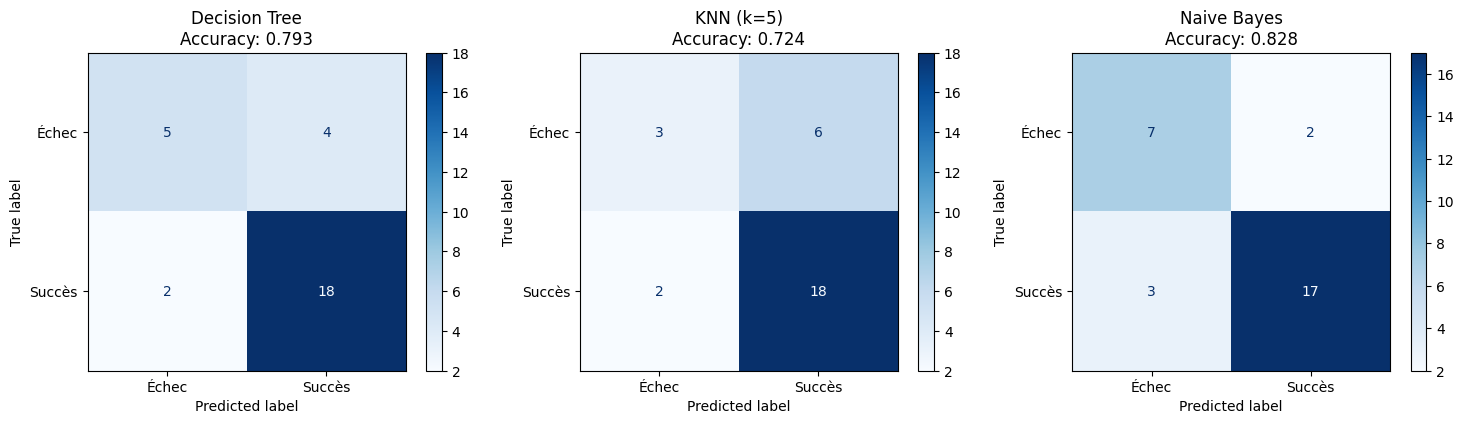


ANALYSE DES MATRICES DE CONFUSION

Decision Tree :
  Vrais Negatifs (Échec prédit correct) : 5
  Faux Positifs (Échec prédit Succès)   : 4
  Faux Négatifs (Succès prédit Échec)   : 2
  Vrais Positifs (Succès prédit correct): 18
  Précision classe Succès : 0.82
  Rappel classe Succès    : 0.90

KNN :
  Vrais Negatifs (Échec prédit correct) : 3
  Faux Positifs (Échec prédit Succès)   : 6
  Faux Négatifs (Succès prédit Échec)   : 2
  Vrais Positifs (Succès prédit correct): 18
  Précision classe Succès : 0.75
  Rappel classe Succès    : 0.90

Naive Bayes :
  Vrais Negatifs (Échec prédit correct) : 7
  Faux Positifs (Échec prédit Succès)   : 2
  Faux Négatifs (Succès prédit Échec)   : 3
  Vrais Positifs (Succès prédit correct): 17
  Précision classe Succès : 0.89
  Rappel classe Succès    : 0.85


In [43]:
# EXERCICE 5 : Matrices de confusion pour les 3 modèles

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Échec", "Succès"])
disp_dt.plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"Decision Tree\nAccuracy: {accuracy_score(y_test, y_pred_dt):.3f}")

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Échec", "Succès"])
disp_knn.plot(ax=axes[1], cmap="Blues")
axes[1].set_title(f"KNN (k=5)\nAccuracy: {accuracy_score(y_test, y_pred_knn):.3f}")

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Échec", "Succès"])
disp_nb.plot(ax=axes[2], cmap="Blues")
axes[2].set_title(f"Naive Bayes\nAccuracy: {accuracy_score(y_test, y_pred_nb):.3f}")

plt.tight_layout()
plt.show()

# Analyse détaillée
print("\n" + "=" * 60)
print("ANALYSE DES MATRICES DE CONFUSION")
print("=" * 60)

for name, cm, y_pred in [("Decision Tree", cm_dt, y_pred_dt), 
                          ("KNN", cm_knn, y_pred_knn), 
                          ("Naive Bayes", cm_nb, y_pred_nb)]:
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name} :")
    print(f"  Vrais Negatifs (Échec prédit correct) : {tn}")
    print(f"  Faux Positifs (Échec prédit Succès)   : {fp}")
    print(f"  Faux Négatifs (Succès prédit Échec)   : {fn}")
    print(f"  Vrais Positifs (Succès prédit correct): {tp}")
    print(f"  Précision classe Succès : {tp/(tp+fp):.2f}" if (tp+fp) > 0 else "  Précision classe Succès : N/A")
    print(f"  Rappel classe Succès    : {tp/(tp+fn):.2f}" if (tp+fn) > 0 else "  Rappel classe Succès : N/A")

EXERCICE 5 :
⛳ TODO Montrer les matrices de confusion sur le dataset. Conclure.

---
## Partie 5 — Clustering non supervisé

On **masque les labels** et on cherche des groupes naturels.
Si les groupes trouvés correspondent à succès/échec, les features portent
bien l'information — indépendamment de la règle RDF.



EXERCICE 6 :
⛳ TODO Lancer un clustering K-means, un clustering hiérarchique ascendant et un DBSCAN (avec entre 1.0 et 1.5 et une minPts entre 4 et 8. Evaluer et conclure.

In [ ]:
pca2 = PCA(n_components=2)
X_2d   = pca2.fit_transform(X_sc)

EXERCICE 6 :

⛳ TODO Interpréter les résultats. Conclure.

---
## Partie 6 — Confronter avec des données réelles (Wikidata)

On envoie une requête SPARQL à l'endpoint public **Wikidata**
pour récupérer des films avec budget et recettes réels,
puis on charge les résultats dans un **second graphe RDF** avec le même schéma.

C'est la démonstration de l'interopérabilité du Web sémantique :
même langage SPARQL, même schéma `cin:`, source différente.

> Propriétés Wikidata : `wdt:P2130` budget · `wdt:P2142` recettes ·

Un **fallback** s'active automatiquement si l'endpoint est inaccessible.


In [46]:
# Requête SPARQL Wikidata
# ── Query enrichie ─────────────────────────────────────────────────────────
WD_QUERY0 = """
SELECT DISTINCT
  ?filmLabel ?budget ?recettes ?annee ?mois
  ?genreLabel ?scoreLabel ?score
WHERE {
  ?film wdt:P31 wd:Q11424 ;
        wdt:P2142 ?recettes ;
        wdt:P2130 ?budget ;
        wdt:P577  ?date .

  BIND(YEAR(?date)  AS ?annee)
  BIND(MONTH(?date) AS ?mois)
  FILTER(?annee >= 2009 && ?annee <= 2021)
  FILTER(?budget > 1000000 && ?recettes > 1000000)

  OPTIONAL { ?film wdt:P136  ?genre }

  OPTIONAL {
    ?film p:P444 ?scoreStmt .
    ?scoreStmt ps:P444 ?score ;
               pq:P447 ?source .
    ?source rdfs:label ?scoreLabel .
    FILTER(LANG(?scoreLabel) = "fr" || LANG(?scoreLabel) = "en")
  }

  SERVICE wikibase:label { bd:serviceParam wikibase:language "fr,en" }
}
GROUP BY ?filmLabel ?budget ?recettes  ?annee ?mois
         ?genreLabel ?scoreLabel ?score
ORDER BY DESC(?recettes)
LIMIT 150
"""

# ── Utilitaire : mois → saison ─────────────────────────────────────────────
def mois_to_saison(mois):
    if mois in (12, 1, 2):  return "hiver"
    if mois in (3, 4, 5):   return "printemps"
    if mois in (6, 7, 8):   return "ete"
    return "automne"

# ── Fetch Wikidata ──────────────────────────────────────────────────────────
def fetch_wikidata(query, timeout=120):
    params = urllib.parse.urlencode({"query": query, "format": "json"})
    req    = urllib.request.Request(
        f"https://query.wikidata.org/sparql?{params}",
        headers={"User-Agent": "TP-Cinema-ML/1.0",
                 "Accept":     "application/sparql-results+json"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return json.loads(resp.read())["results"]["bindings"]

# ── Fallback graphe local ───────────────────────────────────────────────────
def fallback_from_graph():
    qry = prepareQuery("""
        SELECT ?titre ?budget ?recettes  ?genre ?saison
               ?notePresse ?notePublic ?label
        WHERE {
            ?f a ?classe ;
               dc:title        ?titre ;
               cin:budgetM     ?budget ;
               cin:recettesM   ?recettes ;
               cin:label       ?label .
            FILTER(?classe IN (cin:FilmSucces, cin:FilmEchec))
            OPTIONAL { ?f dc:subject   ?genreURI  . ?genreURI rdfs:label ?genre
                          FILTER(LANG(?genre) = "fr") }
            OPTIONAL { ?f foaf:topic   ?saisonURI . ?saisonURI rdfs:label ?saison
                          FILTER(LANG(?saison) = "fr") }
            OPTIONAL { ?f cin:notePresse      ?notePresse }
            OPTIONAL { ?f cin:notePublic      ?notePublic }
        }
    """, initNs={"cin": CIN, "dc": DC, "dcterms": DCTERMS,
                 "rdfs": RDFS, "foaf": FOAF})

    films = []
    for r in g.query(qry):
        films.append({
            "titre"            : str(r.titre),
            "budgetM"          : float(r.budget),
            "recettesM"        : float(r.recettes),
            "annee"            : 2015,
            "mois"             : 6,
            "saison"           : str(r.saison)    if r.saison    else "inconnu",
            "genre"            : str(r.genre)     if r.genre     else "inconnu",
            "notePresse"       : float(r.notePresse) if r.notePresse else None,
            "notePublic"       : float(r.notePublic) if r.notePublic else None,
            "score"            : None,
            "scoreSource"      : None,
            "label"            : int(r.label),
        })
    return films

# ── Parsing des résultats Wikidata ──────────────────────────────────────────
def parse_bindings(bindings):
    films = []
    seen  = set()
    for b in bindings:
        titre = b.get("filmLabel", {}).get("value", "")
        if not titre or titre.startswith("Q") or titre in seen:
            continue
        try:
            bM   = float(b["budget"]["value"])   / 1e6
            rM   = float(b["recettes"]["value"]) / 1e6
            ann  = int(b.get("annee",     {}).get("value", 2015))
            mois = int(b.get("mois",      {}).get("value", 6))
            if bM <= 0:
                continue
            films.append({
                "titre"            : titre,
                "budgetM"          : bM,
                "recettesM"        : rM,
                "annee"            : ann,
                "mois"             : mois,
                "saison"           : mois_to_saison(mois),
                "genre"            : b.get("genreLabel",  {}).get("value", "inconnu"),
                "notePresse"       : None,
                "notePublic"       : None,
                "score"            : b.get("score",       {}).get("value", None),
                "scoreSource"      : b.get("scoreLabel",  {}).get("value", None),
                "label"            : int(rM > 2 * bM),
            })
            seen.add(titre)
        except (KeyError, ValueError):
            continue
    return films

# ── Orchestration ───────────────────────────────────────────────────────────
WIKIDATA_OK = False
FILMS       = []

try:
    print("Connexion Wikidata...", end=" ")
    bindings = fetch_wikidata(WD_QUERY0)
    print(f"OK — {len(bindings)} résultats")
    FILMS       = parse_bindings(bindings)
    WIKIDATA_OK = True
except Exception as e:
    print(f"Echec ({e}) -> fallback graphe local")
    FILMS = fallback_from_graph()

print(f"\nSource   : {'Wikidata' if WIKIDATA_OK else 'graphe local (fallback)'}")
print(f"Films    : {len(FILMS)}")
print(f"\nExemple  : {FILMS[0]}")

Connexion Wikidata... OK — 150 résultats

Source   : Wikidata
Films    : 5

Exemple  : {'titre': 'Ek Tha Tiger', 'budgetM': 950.0, 'recettesM': 3200.0, 'annee': 2012, 'mois': 1, 'saison': 'hiver', 'genre': 'thriller', 'notePresse': None, 'notePublic': None, 'score': '75%', 'scoreSource': 'Rotten Tomatoes', 'label': 1}


EXERCICE 7 :

⛳ TODO Expliquer le code ci dessus.



In [49]:
# ── Encodages ─────────────────────────────────────────────────────────────
GENRES_LISTE = ["action","animation","aventure","biopic","comedie",
                "drame","fantaisie","guerre","horreur","musical",
                "sf","sport","thriller","western"]
GENRES_LIST  = sorted(GENRES_LISTE)
SAISONS_LIST = ["hiver","printemps","ete","automne"]
GENRE_MAP    = {g: i for i, g in enumerate(GENRES_LIST)}
SAISON_MAP   = {s: i for i, s in enumerate(SAISONS_LIST)}

# ── Construction NumPy depuis FILMS ────────────────────────────────────────
TITRES, feats, labels = [], [], []

for f in FILMS:
    TITRES.append(f["titre"])

    g_enc = float(GENRE_MAP.get(f["genre"], -1))   # -1 si genre inconnu
    s_enc = float(SAISON_MAP.get(f["saison"], -1)) # -1 si saison inconnue

    feats.append([
        f["budgetM"],  # budget en M$
        g_enc,         # genre encodé
        s_enc,         # saison encodée
        f["annee"],    # année de sortie
    ])
    labels.append(f["label"])

TITRES_NP = np.array(TITRES)
X_wiki         = np.array(feats)
y_wiki         = np.array(labels)

FEAT_NAMES = ["budget_M", "genre_enc", "saison_enc", "annee"]

print(f"X_wiki : {X_wiki.shape}   y_wiki : {y_wiki.shape}   (succès={y_wiki.sum()}, échecs={(y_wiki==0).sum()})")

X_wiki : (5, 4)   y_wiki : (5,)   (succès=5, échecs=0)


Pouvez-vous appliquer un de vos modèles sur les données réelles, que pouvez-vous en conclure ?

In [50]:
pred_wiki = clf_dt.predict(X_wiki)
print(classification_report(y_reel, pred_wiki))
cm = confusion_matrix(y_reel, pred_wiki, labels=clf_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf_dt.classes_)
disp.plot()
plt.show()

ValueError: X has 4 features, but DecisionTreeClassifier is expecting 8 features as input.

EXERCICE 8 :

⛳ TODO Les features disponibles ne sont pas aussi variées !!! Reprendre les modèles appris plus haut pour pourvoir les appliquer aux données réelles.